<a href="https://colab.research.google.com/github/VishalB210/Carisurg_Week_0_Portfolio/blob/main/Assignment2_PulseCleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving EmergencyTriageDataset_Reduced_Dirty.csv to EmergencyTriageDataset_Reduced_Dirty.csv
Dataset loaded successfully.

   ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR   Fio2
0   1   34       0  15.0   93   67.0   75.67  128.0  36.8  14.0   21.0
1   2   20    Male  15.0  130   90.0  103.33   80.0  37.0  16.0   21.0
2   3   77  Female  14.0  163  105.0  124.33   92.0  36.8  18.0   21.0
3   4   23       0   8.0  100   60.0   73.33  100.0  37.0  12.0  100.0
4   5   86  FEMALE  15.0  150   90.0  110.00   85.0  37.0  19.0   21.0
Pulse values before cleaning:

pulse
80.0     161
100.0    157
90.0     145
110.0    101
85.0      92
120.0     83
88.0      68
70.0      55
95.0      53
84.0      48
82.0      46
78.0      42
Name: count, dtype: int64
Pulse missing after numeric conversion: 44
Pulse out-of-range values: 43
Pulse median used: 90.0
Pulse missing after cleaning: 0
count    2205.000000
mean       94.326984
std        19.881720
min        40.000000
25%        80.000000

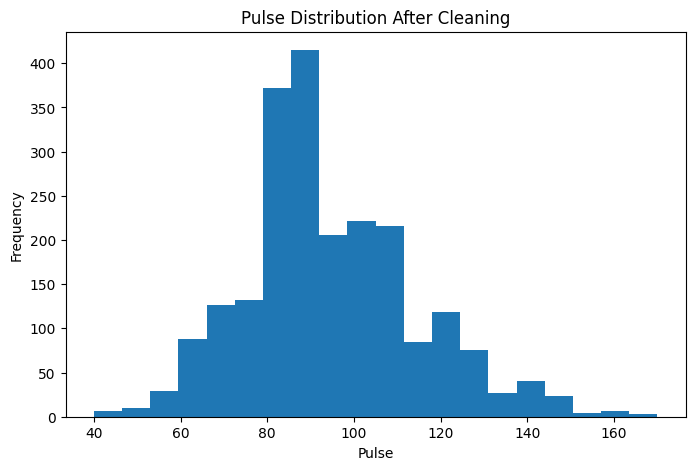

Missing values after cleaning:

pulse    0
dtype: int64

Pulse min after cleaning: 40.0
Pulse max after cleaning: 170.0

Preview of cleaned data:

   ID   GCS  SBP  Temp  pulse
0   1  15.0   93  36.8  128.0
1   2  15.0  130  37.0   80.0
2   3  14.0  163  36.8   92.0
3   4   8.0  100  37.0  100.0
4   5  15.0  150  37.0   85.0
5   6  15.0  100  37.0   99.0
6   7  15.0  120  37.0   99.0
7   8  15.0  100  37.0   85.0
8   9  15.0  110  37.0   78.0
9  11  15.0  153  37.0  130.0
Cleaned dataset saved successfully.


In [1]:
# Assignment 2 - Pulse Column Cleaning

# This notebook demonstrates the cleaning of the Pulse column from the Emergency Triage Dataset.

# The objective is to identify missing, invalid, and out-of-range pulse values and prepare the data for further analysis.

# Import Libraries and Load Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

df = pd.read_csv("EmergencyTriageDataset_Reduced_Dirty.csv")

print("Dataset loaded successfully.\n")

print(df.head())

## Inspecting the Pulse Column

# Before cleaning, the Pulse column is explored to understand the distribution of values and identify any unusual entries.

print("Pulse values before cleaning:\n")

print(df["pulse"].value_counts().head(12))

# Checking for Missing and Invalid Values

# The Pulse column is converted to numeric format. Any non-numeric values are converted to NaN so they can be identified and handled appropriately.

pulse_numeric = pd.to_numeric(
    df["pulse"],
    errors="coerce"
)

print("Pulse missing after numeric conversion:",
      pulse_numeric.isna().sum())

## Creating a Reusable Cleaning Function

# A reusable function is created to clean the Pulse column. The function:

# - Converts values to numeric
# - Identifies unrealistic pulse values
# - Replaces invalid values with NaN
# - Uses median imputation to fill missing values

# Assumption:
# A valid pulse range is between 40 and 170 beats per minute (bpm).

def clean_pulse_column(series):

    # Convert values to numeric
    pulse = pd.to_numeric(
        series,
        errors="coerce"
    )

    # Define valid pulse range
    valid_min = 40
    valid_max = 170

    # Identify impossible values
    out_of_range = (
        (pulse < valid_min) |
        (pulse > valid_max)
    )

    print("Pulse out-of-range values:",
          out_of_range.sum())

    # Replace impossible values with NaN
    pulse.loc[out_of_range] = np.nan

    # Calculate median
    median_pulse = pulse.median()

    print("Pulse median used:",
          median_pulse)

    # Fill missing values with median
    pulse.fillna(
        median_pulse,
        inplace=True
    )

    print("Pulse missing after cleaning:",
          pulse.isna().sum())

    return pulse

# Cleaning the Pulse Column

df["pulse"] = clean_pulse_column(
    df["pulse"]
)

## Summary Statistics After Cleaning

# Descriptive statistics are used to verify that the Pulse column has been successfully cleaned.

print(df["pulse"].describe())

## Visualizing the Cleaned Pulse Data

# A histogram is used to visualize the distribution of pulse values after cleaning.

plt.figure(figsize=(8,5))

plt.hist(
    df["pulse"],
    bins=20
)

plt.title(
    "Pulse Distribution After Cleaning"
)

plt.xlabel("Pulse")

plt.ylabel("Frequency")

plt.show()

## Final Validation Check

# A final validation is performed to ensure that:

# - No missing values remain
# - Pulse values fall within the acceptable range
# - The cleaned data is ready for analysis

print("Missing values after cleaning:\n")

print(
    df[["pulse"]].isna().sum()
)

print("\nPulse min after cleaning:",
      df["pulse"].min())

print("Pulse max after cleaning:",
      df["pulse"].max())

print("\nPreview of cleaned data:\n")

print(
    df[
        [
            "ID",
            "GCS",
            "SBP",
            "Temp",
            "pulse"
        ]
    ].head(10)
)

## Saving the Cleaned Dataset
df.to_csv(
    "EmergencyTriageDataset_Cleaned_Pulse.csv",
    index=False
)

print(
    "Cleaned dataset saved successfully."
)

## Conclusion

# The Pulse column was successfully cleaned by first converting all values to numeric format and identifying invalid entries. Any values outside the accepted physiological range of 40–170 bpm were considered unrealistic and replaced with NaN.

# A total of 44 missing values and 43 out-of-range values were detected. Since the data contained extreme values, the median pulse value of 90 bpm was selected for imputation because it is less sensitive to outliers than the mean.

# After cleaning, all missing values were removed and the Pulse column was validated using summary statistics and a visualization to confirm that the data was ready for further analysis.